In [1]:
import numpy as np
import scipy.stats 
import pylab as plt
import astropy.visualization.hist
from sklearn.neighbors import KernelDensity


For a BH of mass $M$ spin $ \chi\in [0,1] $, the irreducible mass is 
$$
M_{\rm irr} = M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}
$$
For convenience, let us define 

$$f(\chi) = \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}$$

Suppose you have repeated measurments of $M$ and $\chi$. This is just because we're still frequentists for now. When we will put our Bayesian hat on, these distributions will be the *posterior samples* from a single measurement.

Let's assume that

- the spin $\chi$ is uniformly distributed between 0 and 1.
- the mass $M$ is normally distributed with mean $\mu$ and standard deviation $\sigma$.
- (masses and spins are uncorrelated)

These are simplistic assumption that, however, are not too far from what we are now measuring with gravitational-wave detectors. It's a toy model, but not a totally unreasonable one.

**Tasks**:

1. Start with a value of $\sigma=0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a dimension of mass by $\mu$. Just set $\mu=1$ in your code and remember that all masses in the problem are measured in units of $\mu$. 

In [2]:
N = 10000 # Number of samples

# M  samples
mu = 1
sigma = 0.02
m = scipy.stats.norm(loc = mu, scale= sigma)
x = (m.rvs(N))

# Ki samples
ki = scipy.stats.uniform(loc = 0, scale= 1)
y = (ki.rvs(N))


def f(i):
    return np.sqrt((1+np.sqrt(1-i**2))/2)

M_irr = x*f(y)

#### BE CAREFULL WHEN YOU USE `Density = True` in the plot!!!

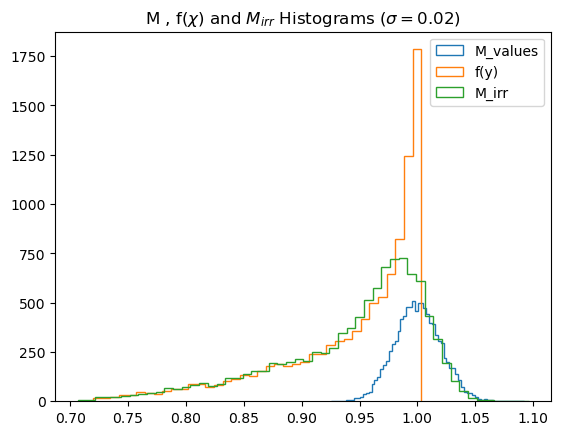

In [3]:
astropy.visualization.hist(x, bins= 'freedman', histtype='step', label='M_values')
astropy.visualization.hist(f(y), bins= 'freedman', histtype='step', label='f(y)')
astropy.visualization.hist(M_irr,bins='freedman', histtype='step', label='M_irr')
plt.title('M , f($\chi$) and $M_{irr}$ Histograms ($\sigma = $'+str(sigma)+')')
plt.legend();

2. Plot the resulting pdf of $M_{\rm irr}$. First try an histogram with one the rules of thumb we've seen above.

*Hint (for point 2)*: You don't know the functional form of the pdf of $M_{\rm irr}$... but you don't need it if you just want to generate samples! That's the nice thing about numerics!

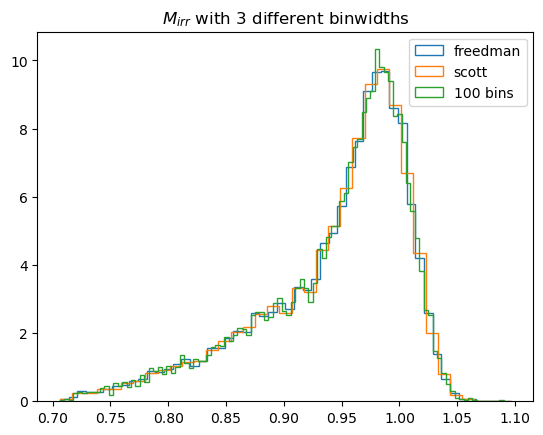

In [4]:
astropy.visualization.hist(M_irr,bins="freedman",density=True,histtype='step', label= 'freedman')
astropy.visualization.hist(M_irr,bins="scott",density=True,histtype='step', label= 'scott')
plt.hist(M_irr,bins=100,density=True,histtype='step', label= '100 bins')
plt.title('$M_{irr}$ with 3 different binwidths')
plt.legend();

3. Using the same samples, plot the distribution of $M_{\rm irr}$ using a KDE.

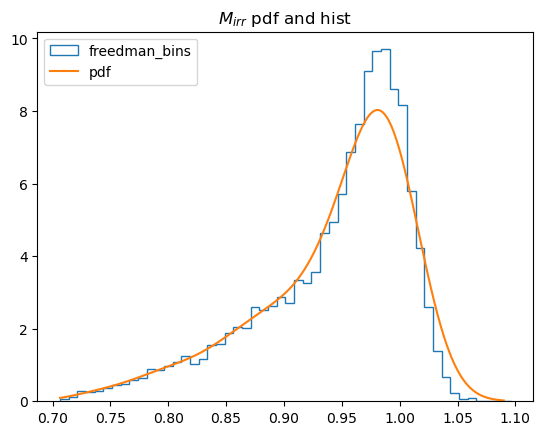

In [ ]:
xgrid = np.linspace(M_irr.min(), M_irr.max(), N)

def kde_sklearn(data,grids, bandwidth, kernel="gaussian"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(grids[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

pdf_M_irr = kde_sklearn(M_irr, xgrid, 0.015)

astropy.visualization.hist(M_irr,bins="freedman",density=True,histtype='step', label= 'freedman_bins')
plt.plot(xgrid,pdf_M_irr, label= 'pdf')
plt.title('$M_{irr}$ pdf and hist')
plt.legend();


4. Compute the KS distance between ${M_{\rm irr}}/\mu$ and ${f}$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$. 
5. Compute the KS distance between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

*Hint (for points 4 and 5)*. This is a KS test between two sets for samples, `scipy.stats.ks_2samp`.

You should find that (i) $M_{\rm irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and (ii) $M_{\rm irr}$ is distributed like $M$ if  $\sigma\gg \mu$.

In [6]:
sig_list = np.logspace(-5, 5, 100)

M_irr_list = []
x_list = []
ks_dist_f = []
ks_dist_m = []

for s in sig_list:

 m = scipy.stats.norm(loc = mu, scale= s)
 x = m.rvs(N)
 
 x_list.append(x)
 M_irr_list.append(x*f(y)) 
 ks_dist_f.append(scipy.stats.ks_2samp(x*f(y),f(y)))
 ks_dist_m.append(scipy.stats.ks_2samp(x*f(y),x))

ks_dist_m = np.array(ks_dist_m)
ks_dist_f = np.array(ks_dist_f)

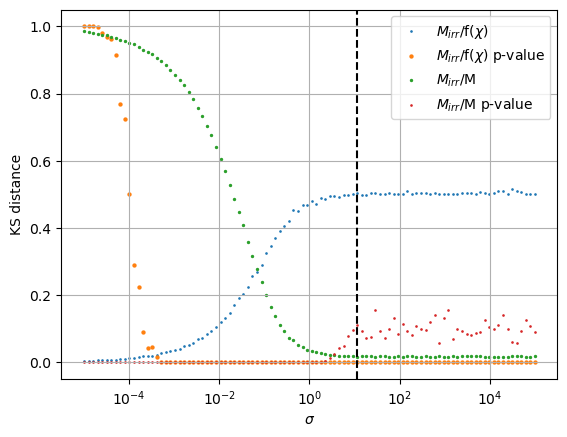

In [7]:
plt.scatter(sig_list,ks_dist_f[:,0], s= 0.8,label= '$M_{irr}$/f($\chi$)')
plt.scatter(sig_list,ks_dist_f[:,1], s= 4.5,label= '$M_{irr}$/f($\chi$) p-value')
plt.scatter(sig_list,ks_dist_m[:,0], s= 2,label= '$M_{irr}$/M')
plt.scatter(sig_list,ks_dist_m[:,1], s= 0.8,label= '$M_{irr}$/M p-value')
plt.axvline(sig_list[60], c='black', ls= 'dashed')  # Compare it with the first histogram in this notebook
plt.xscale('log')
plt.xlabel("$\sigma$")
plt.ylabel('KS distance')
plt.grid()
plt.legend();

---

### **Gaussian distribution** -> Check the change in sigma when it goes to zero or for a very high value:
$$p(x|\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(\frac{-(x-\mu)^2}{2\sigma^2}\right)$$

* **NOTE:** M won't change much at low or high $\sigma$ values

1. If $\sigma$ goes to 0, `x` values range becomes narrow and concentrated around $\mu = 1$, then $M = 1$ and 
$$
M_{irr} = f(\chi)$$

   * For $M_{irr}/f$ KS distance, it would go to zero as the functions are almost identical
   * For $M_{irr}/M$ KS distance, it would go to one (They are normalized in the `ks` code).

2. If $\sigma$ goes to $\infty$ , `x` values range becomes wide and f($\chi$) will be negligibale, then 
$$
M_{irr} = M$$

### **p-value** -> It represents if the values of the functions are drawn from the same distribution. For Example:
* **Check the first histogram with the appropriate `sigma` each time for the following:**
* At high $\sigma$ values, The red ($M_{irr}$/M) scatter indicates that both distribution values are mostly drawn from the same pdf. 
* At low $\sigma$ values, The green ($M_{irr}$/f($\chi$)) scatter indicates that both distribution values are drawn from the same pdf. 
* Note that the p-value max of the green goes to 1 while the max red is 0.16. Although, just try with low `N` and p values will go to 1 for both. **For low `N`, the test won't notice the noise (differences between the 2 distributions), so, p-value goes close to 1**

* When you run ks_2samp, the code computes your D statistic (the maximum gap between your two curves). It then looks at the area under that mathematical curve starting from your D value out to infinity.
* Check [this website]('https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.stats.ks_2samp.html') for more details abourt the `kstest` and `ks_2samp`.
---

7. [**Optional, not examinable**] Compute the pdf of $f$ from its mathematical definition (pen and paper!). Verify this result: 

$$
\pi(f) = 2\frac{2 f^2-1}{\sqrt{1 - f^2}}\,.
$$

8. [**Optional, not examinable**]  Compute the pdfs of $M_{\rm irr}$ from its mathematical definition (pen and paper!). Verify this result:

$$
p(M_{\rm irr})  = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[{-\frac{(M_{\rm irr}/f -\mu)^2}{2\sigma^2}}\right]  \frac{2 f^2-1}{f \sqrt{1 - f^2}}  \,\, {\rm d}f\,. 
$$

The this expression is only semi-analytic; that integral should then be solved numerically.

*Hint (for point 8)*: You want to use [this theorem](https://en.wikipedia.org/wiki/Distribution_of_the_product_of_two_random_variables) for the product of two random variables. 

9. Using the expressions from point 7 and 8, plot those pdfs check that they agree with your KDE reconstructions.

In [8]:
def pi(f):
    return 2 * (2 * f**2 - 1) / np.sqrt(1 - f**2)
def dp(m,s,f):
    term1 = np.sqrt(2 / np.pi) / s
    exponent = -((m / f - 1)**2) / (2 * s**2)
    pipi = (2 * f**2 - 1) / (f * np.sqrt(1 - f**2))
    return term1 * np.exp(exponent) * pipi

N = 10000 # Number of samples

# M  samples
mu = 1
sigma = 0.02
m = scipy.stats.norm(loc = mu, scale= sigma)
x = (m.rvs(N))

M_irr = x*f(y)

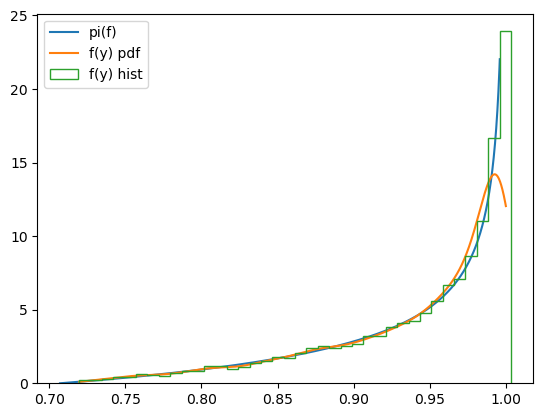

In [39]:
xmin, xmax = 1/np.sqrt(2) , 1
xgrid_f = np.linspace(xmin,xmax-0.004,N)
ff = pi(xgrid_f)

pdf_f = kde_sklearn(f(y), np.sort(f(y)),  0.01) # Remember: the last value is the bandwidth.


plt.plot(xgrid_f,ff, label= 'pi(f)')
plt.plot(np.sort(f(y)),pdf_f , label = 'f(y) pdf')
astropy.visualization.hist(f(y), bins= 'freedman', histtype='step', label='f(y) hist', density = True)
plt.legend();

### They are almost the same, chaning the `bandwidth` and the `xgrid_f` would make them identical
---

In [40]:
mgrid = np.linspace(xmin,xmax+1,N)

def integ(m):
 return (xmax-xmin)*np.mean(dp(m,sigma,xgrid_f))

bw = 0.025
p_M = [integ(i) for i in mgrid]
pdf_M_irr = kde_sklearn(M_irr, xgrid, bw)

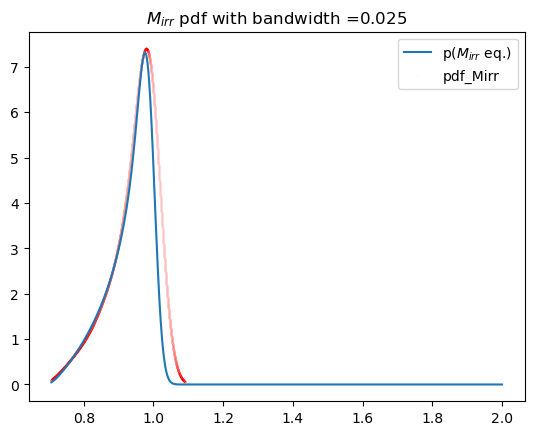

In [41]:

plt.plot(mgrid, p_M, label= 'p($M_{irr}$ eq.)')
plt.scatter(xgrid,pdf_M_irr, s=0.001, alpha=0.5, label= 'pdf_Mirr', color='red')
plt.title('$M_{irr}$ pdf with bandwidth ='+str(bw))
plt.legend();